# Image Segmenation: SAM 2.1

In [1]:
!pip install sam2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 5.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 2.8 MB/s eta 0:00:00
  Created wheel for sam2: filename=sam2-1.1.0-py3-none-any.whl size=183699 sha256=99612516e2d9b3b3b07b924aea51b30828da75c723f073a6d639e4415ebe9ee3
  Stored in directory: /root/.cache/pip/wheels/22/cb/54/0351e695a7a2e8eed8d5987cd02d8e5227eec87b0bbcc00094
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=6a821c732698e686e9c4f24b87c343ffcdaee467300df4e192fa03daf03b94be
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4

## Train SAM Model

### Create Masks

In [2]:
import cv2
import numpy as np
import glob
# Define exact target RGB color ranges for each class
COLOR_TO_CLASS = {
    # Color (R, G, B) : Class ID
    (231, 25, 31): 1,      # Red (Fairway)
    (250, 255, 0): 2,    # Yellow (Rough)
    (255, 166, 41): 3,    # Orange (Sand)
    (13, 153, 255): 4,    # Blue (Water)
    (151, 71, 255): 5,    # Purple (Trees)
    (20, 174, 92): 6,      # Green (Putting Green)
    (0, 232, 255): 7,    # Cyan (Cart path)
    # (255, 0, 214): 8,    # Pink (UI, User Interface)
}

def create_mask(filename):
    # Load colored mask image
    mask_rgb = cv2.imread(filename)
    mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)

    # Initialize output class mask (same H x W, initialized to background = 0)
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)

    # Map each RGB color to its respective class ID
    for color, class_id in COLOR_TO_CLASS.items():
        # Find pixels matching the color (with small tolerance for compression artifacts)
        lower = np.array([max(0, c - 15) for c in color], dtype=np.uint8)
        upper = np.array([min(255, c + 15) for c in color], dtype=np.uint8)

        match = cv2.inRange(mask_rgb, lower, upper)
        class_mask[match > 0] = class_id

    # Save as a single-channel grayscale PNG mask (values 0, 1, 2, ...)
    cv2.imwrite(f"mask_{filename.replace('.png', '')}.png", class_mask)
    print("Conversion complete! Class mask saved.")

segmented_files = glob.glob("segmented_*")

for file in segmented_files:
    create_mask(file)

Conversion complete! Class mask saved.
Conversion complete! Class mask saved.
Conversion complete! Class mask saved.
Conversion complete! Class mask saved.
Conversion complete! Class mask saved.
Conversion complete! Class mask saved.


### Dataset

In [3]:
# Set up files like this:

# dataset/
# ├── images/
# │   ├── img1.jpg
# │   └── img2.jpg
# └── masks/
#     ├── img1.png  # Binary mask (0 = background, 255 = target)
#     └── img2.png

import os
import shutil
import glob

# Make folders
os.makedirs("dataset/images", exist_ok=True)
os.makedirs("dataset/masks", exist_ok=True)

# Move images and masks to folders
tournament_files = glob.glob("tournament_*")
print(tournament_files)
mask_files = glob.glob("mask_*")
print(mask_files)

for file in tournament_files:
    shutil.move(file, "dataset/images")

for file in mask_files:
    shutil.move(file, "dataset/masks")

['tournament_R2026011_player_46046_hole_16_round_4.png', 'tournament_R2021011_player_25804_hole_1_round_1.png', 'tournament_R2025011_player_24502_hole_3_round_2.png', 'tournament_R2026011_player_46046_hole_17_round_4.png', 'tournament_R2025011_player_23108_hole_5_round_4.png', 'tournament_R2025011_player_24502_hole_2_round_1.png']
['mask_segmented_tournament_R2026011_player_46046_hole_16_round_4_no_ui.png', 'mask_segmented_tournament_R2025011_player_24502_hole_3_round_2_no_ui.png', 'mask_segmented_tournament_R2025011_player_24502_hole_2_round_1_no_ui.png', 'mask_segmented_tournament_R2026011_player_46046_hole_17_round_4_no_ui.png', 'mask_segmented_tournament_R2021011_player_25804_hole_1_round_1_no_ui.png', 'mask_segmented_tournament_R2025011_player_23108_hole_5_round_4_no_ui.png']


In [4]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF

class CustomSAM2Dataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=(512, 512)):
        self.image_paths = glob.glob(f"{image_dir}/*")
        self.mask_paths = glob.glob(f"{mask_dir}/*")
        self.img_size = img_size

    def __getitem__(self, idx):
        # Load image and mask
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Convert to Tensor (C, H, W)
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0).long()

        # Resize both to uniform dimensions
        # Use InterpolationMode.NEAREST for masks to avoid corrupting integer class labels
        image = TF.resize(image, self.img_size, interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.img_size, interpolation=TF.InterpolationMode.NEAREST)
        mask = (mask > 0).float() # Ensure binary format (0 or 1)

        # Extract bounding box prompt [x_min, y_min, x_max, y_max]
        y_indices, x_indices = np.where(mask.squeeze(0) > 0)
        if len(x_indices) > 0 and len(y_indices) > 0:
            bbox = np.array([np.min(x_indices), np.min(y_indices), np.max(x_indices), np.max(y_indices)])
        else:
            bbox = np.array([0, 0, image.shape[1], image.shape[0]])

        return {"image": image, "mask": mask, "bbox": torch.tensor(bbox).float()}

    def __len__(self):
        return len(self.image_paths)

### Training Loop

In [5]:
# !wget -O sam2_hiera_small.pt "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt"
!wget -O sam2.1_hiera_small.pt "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt"

--2026-08-07 21:53:21--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.167.112.129, 3.167.112.53, 3.167.112.66, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.167.112.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184416285 (176M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2.1_hiera_small.pt’

sam2.1_hiera_small. 100%[===================>] 175.87M   370MB/s    in 0.5s    

2026-08-07 21:53:21 (370 MB/s) - ‘sam2.1_hiera_small.pt’ saved [184416285/184416285]



In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sam2.build_sam import build_sam2

# 1. Build Model
# sam2_checkpoint = "sam2_hiera_small.pt"
# model_cfg = "sam2_hiera_s.yaml" # Config matching checkpoint size
sam2_checkpoint = "sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = build_sam2(model_cfg, sam2_checkpoint, device=device)

# 2. Freeze Image Encoder & Prompt Encoder parameters
for param in model.image_encoder.parameters():
    param.requires_grad = False

for param in model.sam_prompt_encoder.parameters():
    param.requires_grad = False

# Enable gradient updates only for Mask Decoder
for param in model.sam_mask_decoder.parameters():
    param.requires_grad = True

# 3. Define Optimizer & Loss Function (Combination of BCE Loss + Dice Loss)
optimizer = optim.AdamW(model.sam_mask_decoder.parameters(), lr=1e-4, weight_decay=1e-2)

def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(-2, -1))
    union = pred.sum(dim=(-2, -1)) + target.sum(dim=(-2, -1))
    return 1 - ((2. * intersection + smooth) / (union + smooth)).mean()

bce_loss = nn.BCEWithLogitsLoss()

In [7]:
train_dataset = CustomSAM2Dataset(image_dir="dataset/images", mask_dir="dataset/masks")
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

epochs = 50

for epoch in range(epochs):
    epoch_loss = 0.0

    for batch in train_loader:

        images = batch["image"].to(device)
        gt_masks = batch["mask"].to(device)
        bboxes = batch["bbox"].to(device)

        optimizer.zero_grad()

        # Step A: Extract SAM2 image features
        with torch.no_grad():
            backbone_out = model.forward_image(images)

            image_embeddings = backbone_out["vision_features"]
            if isinstance(image_embeddings, list):
                image_embeddings = image_embeddings[0]

            if image_embeddings.dim() == 3:
                image_embeddings = image_embeddings.unsqueeze(0)

            high_res_features = [
                backbone_out["backbone_fpn"][0],
                backbone_out["backbone_fpn"][1],
            ]
            # print("High resolution features:")
            # for f in high_res_features:
            #     print(f.shape)

            image_pe = backbone_out["vision_pos_enc"][-1][:1]

        # Step B: Encode box prompts
        sparse_embeddings, dense_embeddings = model.sam_prompt_encoder(
            points=None,
            boxes=bboxes,
            masks=None,
        )

        # Match image embedding spatial size
        dense_embeddings = torch.nn.functional.interpolate(
            dense_embeddings,
            size=image_embeddings.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        # print("Image:", image_embeddings.shape)
        # print("PE:", image_pe.shape)
        # print("Dense:", dense_embeddings.shape)

        # Step C: Decode mask
        low_res_masks, iou_predictions, _, _ = model.sam_mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=image_pe,
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            high_res_features=high_res_features,
            repeat_image=False,
            multimask_output=False,
        )

        # Step D: Upsample prediction
        pred_masks = torch.nn.functional.interpolate(
            low_res_masks,
            size=gt_masks.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        # Step E: Loss
        loss = (
            bce_loss(pred_masks, gt_masks)
            + dice_loss(pred_masks, gt_masks)
        )


        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()


    avg_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.4f}"
    )


# Save fine-tuned weights
torch.save(
    model.state_dict(),
    "sam2_custom_finetuned.pt"
)

print("Model saved successfully!")

Epoch [1/50] Loss: 4.5631
Epoch [2/50] Loss: 1.0333
Epoch [3/50] Loss: 0.9244
Epoch [4/50] Loss: 0.8852
Epoch [5/50] Loss: 0.9363
Epoch [6/50] Loss: 0.8784
Epoch [7/50] Loss: 0.7405
Epoch [8/50] Loss: 0.6823
Epoch [9/50] Loss: 0.7038
Epoch [10/50] Loss: 0.7385
Epoch [11/50] Loss: 0.6889
Epoch [12/50] Loss: 0.6705
Epoch [13/50] Loss: 0.6144
Epoch [14/50] Loss: 0.5559
Epoch [15/50] Loss: 0.5359
Epoch [16/50] Loss: 0.5507
Epoch [17/50] Loss: 0.5343
Epoch [18/50] Loss: 0.4696
Epoch [19/50] Loss: 0.5113
Epoch [20/50] Loss: 0.5080
Epoch [21/50] Loss: 0.4423
Epoch [22/50] Loss: 0.4801
Epoch [23/50] Loss: 0.4723
Epoch [24/50] Loss: 0.4681
Epoch [25/50] Loss: 0.4195
Epoch [26/50] Loss: 0.4148
Epoch [27/50] Loss: 0.4083
Epoch [28/50] Loss: 0.3931
Epoch [29/50] Loss: 1.1142
Epoch [30/50] Loss: 0.4242
Epoch [31/50] Loss: 0.4205
Epoch [32/50] Loss: 0.4611
Epoch [33/50] Loss: 0.4211
Epoch [34/50] Loss: 0.5311
Epoch [35/50] Loss: 0.4904
Epoch [36/50] Loss: 0.4545
Epoch [37/50] Loss: 0.4790
Epoch [38/

## Auto Mask Generation Results

In [8]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "sam2_custom_finetuned.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_custom = build_sam2(
    model_cfg,
    checkpoint=None,
    device=device,
    apply_postprocessing=False,
)

state_dict = torch.load(
    sam2_checkpoint,
    map_location=device
)

sam2_custom.load_state_dict(state_dict)

sam2_custom.eval()

mask_generator = SAM2AutomaticMaskGenerator(sam2_custom)

In [10]:
image = cv2.imread("/content/dataset/tournament_R2025011_player_23108_hole_5_round_4.png")
masks = mask_generator.generate(image)

In [11]:
print(len(masks))
print(masks[0].keys())

41
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


In [12]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1)

    ax.imshow(img)

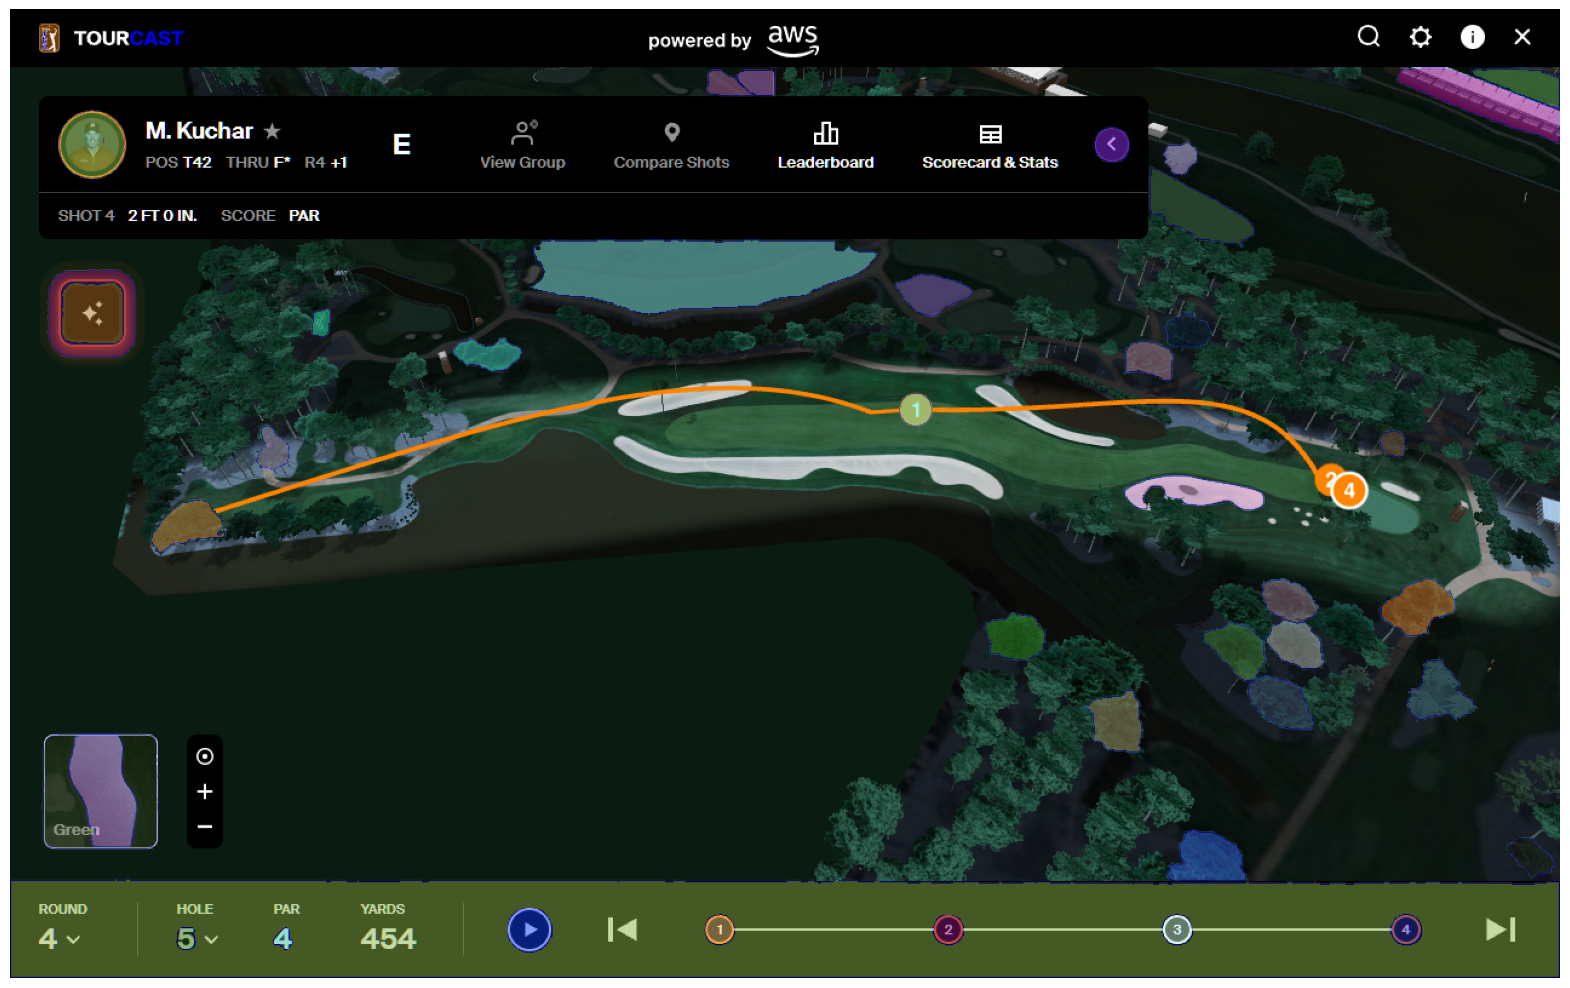

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()